<center><h1 style="color:purple"><b>Fashion MNIST Dataset: Simple Neural Network</b></h1></center>

This is my first Neural Network Code on Kaggle. Here I am trying to show how categorical_crossentropy and sparse_categorical_crossenrtropy differs. Constructive Criticisms are welcome.

Both categorical cross entropy and sparse categorical cross-entropy have the same loss function. The only difference between the two is on how truth labels are defined.
- Categorical cross-entropy is used when true labels are one-hot encoded, for example, we have the following true values for 3-class classification problem [1,0,0], [0,1,0] and [0,0,1].
- In sparse categorical cross-entropy , truth labels are integer encoded, for example, [1], [2] and [3] for 3-class problem.

To read more about loss functions, click [here](https://towardsdatascience.com/cross-entropy-loss-function-f38c4ec8643e)

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np

In [2]:
(trainX,trainY),(testX,testY) = tf.keras.datasets.fashion_mnist.load_data()

4431872/4422102 [==============================] - 0s 0us/step


In [3]:
print(trainX.shape)
print(trainY.shape)
print(testX.shape)
print(testY.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
np.set_printoptions(linewidth = 200)

In [5]:
trainX[5]

array([[  0,   0,   0,   0,   1,   0,   0,   0,   0,  22,  88, 188, 172, 132, 125, 141, 199, 143,   9,   0,   0,   0,   1,   0,   0,   0,   0,   0],
       [  0,   0,   0,   1,   0,   0,  20, 131, 199, 206, 196, 202, 242, 255, 255, 250, 222, 197, 206, 188, 126,  17,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   1,   0,  35, 214, 191, 183, 178, 175, 168, 150, 162, 159, 152, 158, 179, 183, 189, 195, 185,  82,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 170, 190, 172, 177, 176, 171, 169, 162, 155, 148, 154, 169, 174, 175, 175, 177, 183, 188,  12,   0,   0,   0,   0],
       [  0,   0,   0,   0,  25, 194, 180, 178, 174, 184, 187, 189, 187, 184, 181, 189, 200, 197, 193, 190, 178, 175, 194,  90,   0,   0,   0,   0],
       [  0,   0,   0,   0,  42, 218, 191, 197, 208, 204, 211, 209, 210, 212, 211, 214, 215, 213, 214, 211, 211, 191, 200, 158,   0,   0,   0,   0],
       [  0,   0,   0,   0,  88, 221, 215, 217, 219, 211, 185, 150, 118, 107,  99,  88,  83,  90, 135, 212

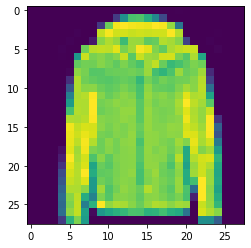

In [6]:
import matplotlib.pyplot as plt
plt.imshow(trainX[5000])

In [7]:
#Preprocess data
trainX = trainX/255.0
testX = testX/255.0

## With Categorical CrossEntropy

In [8]:
trainY1 = tf.keras.utils.to_categorical(trainY, num_classes=10)
testY1 = tf.keras.utils.to_categorical(testY, num_classes=10)

In [9]:
# Model Building with Dense 100 and Dense 10
tf.keras.backend.clear_session()

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28,)))
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))


User settings:

   KMP_AFFINITY=granularity=fine,verbose,compact,1,0
   KMP_BLOCKTIME=0
   KMP_SETTINGS=1
   KMP_WARNINGS=0

Effective settings:

   KMP_ABORT_DELAY=0
   KMP_ADAPTIVE_LOCK_PROPS='1,1024'
   KMP_ALIGN_ALLOC=64
   KMP_ALL_THREADPRIVATE=128
   KMP_ATOMIC_MODE=2
   KMP_BLOCKTIME=0
   KMP_CPUINFO_FILE: value is not defined
   KMP_DETERMINISTIC_REDUCTION=false
   KMP_DEVICE_THREAD_LIMIT=2147483647
   KMP_DISP_NUM_BUFFERS=7
   KMP_DUPLICATE_LIB_OK=false
   KMP_ENABLE_TASK_THROTTLING=true
   KMP_FORCE_REDUCTION: value is not defined
   KMP_FOREIGN_THREADS_THREADPRIVATE=true
   KMP_FORKJOIN_BARRIER='2,2'
   KMP_FORKJOIN_BARRIER_PATTERN='hyper,hyper'
   KMP_GTID_MODE=3
   KMP_HANDLE_SIGNALS=false
   KMP_HOT_TEAMS_MAX_LEVEL=1
   KMP_HOT_TEAMS_MODE=0
   KMP_INIT_AT_FORK=true
   KMP_LIBRARY=throughput
   KMP_LOCK_KIND=queuing
   KMP_MALLOC_POOL_INCR=1M
   KMP_NUM_LOCKS_IN_BLOCK=1
   KMP_PLAIN_BARRIER='2,2'
   KMP_PLAIN_BARRIER_PATTERN='hyper,hyper'
   KMP_REDUCTION_BARRIER='1,1'
  

In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 100)               78500     
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1010      
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
_________________________________________________________________


In [11]:
#sgd_optimzer = tf.keras.optimizers.SGD(learning_rate = 0.03)

model.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])

In [12]:
# fitting the model
history = model.fit(trainX,trainY1, epochs = 10, validation_data=(testX,testY1), batch_size = 512)

2021-10-23 18:08:49.850319: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/10
118/118 [==============================] - 1s 7ms/step - loss: 0.7264 - accuracy: 0.7560 - val_loss: 0.5395 - val_accuracy: 0.8103
Epoch 2/10
118/118 [==============================] - 1s 5ms/step - loss: 0.4753 - accuracy: 0.8378 - val_loss: 0.4798 - val_accuracy: 0.8311
Epoch 3/10
118/118 [==============================] - 1s 5ms/step - loss: 0.4316 - accuracy: 0.8522 - val_loss: 0.4596 - val_accuracy: 0.8372
Epoch 4/10
118/118 [==============================] - 1s 5ms/step - loss: 0.4074 - accuracy: 0.8576 - val_loss: 0.4400 - val_accuracy: 0.8470
Epoch 5/10
118/118 [==============================] - 1s 5ms/step - loss: 0.3883 - accuracy: 0.8639 - val_loss: 0.4294 - val_accuracy: 0.8499
Epoch 6/10
118/118 [==============================] - 1s 5ms/step - loss: 0.3700 - accuracy: 0.8705 - val_loss: 0.4083 - val_accuracy: 0.8549
Epoch 7/10
118/118 [==============================] - 1s 5ms/step - loss: 0.3586 - accuracy: 0.8729 - val_loss: 0.3978 - val_accuracy: 0.8586
Epoch 

In [13]:
#Model Evaluation
test_loss, test_acc= model.evaluate(testX,testY1,verbose=2)

313/313 - 0s - loss: 0.3884 - accuracy: 0.8610


In [14]:
#modifiedthe model to Dense 300 and Dense 10
model2 = tf.keras.Sequential()
model2.add(tf.keras.layers.Flatten(input_shape=(28,28,)))
model2.add(tf.keras.layers.Dense(300, activation='relu'))
model2.add(tf.keras.layers.Dense(10, activation='softmax'))

In [15]:
model2.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 300)               235500    
_________________________________________________________________
dense_3 (Dense)              (None, 10)                3010      
Total params: 238,510
Trainable params: 238,510
Non-trainable params: 0
_________________________________________________________________


In [16]:
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
model2.fit(trainX, trainY1, epochs=10, batch_size=512, validation_data=(testX,testY1))

Epoch 1/10
118/118 [==============================] - 1s 9ms/step - loss: 0.6146 - accuracy: 0.7911 - val_loss: 0.4900 - val_accuracy: 0.8320
Epoch 2/10
118/118 [==============================] - 1s 8ms/step - loss: 0.4272 - accuracy: 0.8523 - val_loss: 0.4460 - val_accuracy: 0.8431
Epoch 3/10
118/118 [==============================] - 1s 13ms/step - loss: 0.3834 - accuracy: 0.8671 - val_loss: 0.4080 - val_accuracy: 0.8551
Epoch 4/10
118/118 [==============================] - 1s 8ms/step - loss: 0.3589 - accuracy: 0.8742 - val_loss: 0.4040 - val_accuracy: 0.8566
Epoch 5/10
118/118 [==============================] - 1s 8ms/step - loss: 0.3366 - accuracy: 0.8811 - val_loss: 0.4140 - val_accuracy: 0.8494
Epoch 6/10
118/118 [==============================] - 1s 7ms/step - loss: 0.3243 - accuracy: 0.8830 - val_loss: 0.3589 - val_accuracy: 0.8711
Epoch 7/10
118/118 [==============================] - 1s 8ms/step - loss: 0.3048 - accuracy: 0.8914 - val_loss: 0.3517 - val_accuracy: 0.8769
Epoch

In [18]:
#MOdel Prediction
predictions = model2.predict(testX)
predictions[0]

array([1.59351259e-06, 1.01166776e-07, 1.55751059e-06, 8.74350619e-08, 6.72764997e-07, 2.49529537e-03, 1.88002105e-06, 1.09572764e-02, 1.60398253e-04, 9.86381114e-01], dtype=float32)

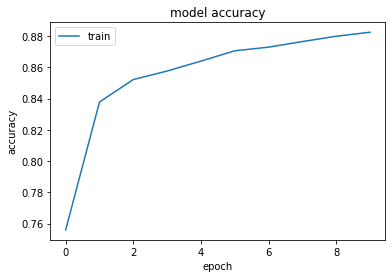

In [19]:
#plotting accuracy
plt.plot(history.history['accuracy'])
#plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

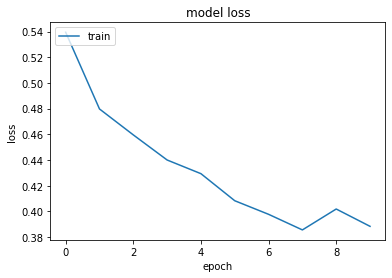

In [20]:
# plotting loss
#plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [21]:
from sklearn import metrics
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report

predy = [np.argmax(i) for i in predictions]
testy2 = [np.argmax(i) for i in testY1]

matrix =metrics.confusion_matrix(testy2,predy)
matrix

array([[843,   0,  13,  43,   5,   0,  84,   0,  12,   0],
       [  3, 969,   0,  21,   4,   0,   2,   0,   1,   0],
       [ 20,   1, 761,  15, 141,   0,  55,   0,   7,   0],
       [ 22,   8,   8, 909,  33,   0,  15,   0,   5,   0],
       [  0,   1,  69,  28, 862,   1,  35,   0,   4,   0],
       [  0,   0,   0,   1,   0, 945,   0,  29,   2,  23],
       [136,   1,  94,  43, 103,   0, 607,   0,  16,   0],
       [  0,   0,   0,   0,   0,  12,   0, 891,   0,  97],
       [  3,   1,   4,   5,   6,   1,   0,   5, 975,   0],
       [  0,   0,   0,   0,   0,   4,   1,  14,   0, 981]])

In [22]:
df = pd.DataFrame(matrix)
df

,0,1,2,3,4,5,6,7,8,9
0,843,0,13,43,5,0,84,0,12,0
1,3,969,0,21,4,0,2,0,1,0
2,20,1,761,15,141,0,55,0,7,0
3,22,8,8,909,33,0,15,0,5,0
4,0,1,69,28,862,1,35,0,4,0
5,0,0,0,1,0,945,0,29,2,23
6,136,1,94,43,103,0,607,0,16,0
7,0,0,0,0,0,12,0,891,0,97
8,3,1,4,5,6,1,0,5,975,0
9,0,0,0,0,0,4,1,14,0,981


In [23]:
summ = []
sc = 0
for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        if i!=j:
            sc = sc + df[i][j]
    summ.append(sc)
    sc = 0
    
# Number of correct and incorrect predictions in each class
df2 = pd.DataFrame()
df2['Class'] = df.columns
df2['Num. of incorrect predictions'] = summ
df2['Num of correct predictions'] = pd.Series(np.diag(df))

In [24]:
df2

,Class,Num. of incorrect predictions,Num of correct predictions
0,0,184,843
1,1,12,969
2,2,188,761
3,3,156,909
4,4,292,862
5,5,18,945
6,6,192,607
7,7,48,891
8,8,47,975
9,9,120,981


In [25]:
print(classification_report(testy2,predy))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.80      0.76      0.78      1000
           3       0.85      0.91      0.88      1000
           4       0.75      0.86      0.80      1000
           5       0.98      0.94      0.96      1000
           6       0.76      0.61      0.67      1000
           7       0.95      0.89      0.92      1000
           8       0.95      0.97      0.96      1000
           9       0.89      0.98      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [26]:
report = classification_report(testy2, predy, output_dict=True)

In [27]:
#Precision, recall and F1 score as data frame for each class
df3 = pd.DataFrame(report).transpose()
df3

,precision,recall,f1-score,support
0,0.820837,0.8430,0.831771,1000.0000
1,0.987768,0.9690,0.978294,1000.0000
2,0.801897,0.7610,0.780913,1000.0000
3,0.853521,0.9090,0.880387,1000.0000
4,0.746967,0.8620,0.800371,1000.0000
5,0.981308,0.9450,0.962812,1000.0000
6,0.759700,0.6070,0.674819,1000.0000
7,0.948882,0.8910,0.919030,1000.0000
8,0.954012,0.9750,0.964392,1000.0000
9,0.891008,0.9810,0.933841,1000.0000


In [28]:
df3 = df3.iloc[0:10,:]
df4 = pd.concat([df2.reset_index(drop = True),df3.reset_index(drop = True)], axis=1)
df4

,Class,Num. of incorrect predictions,Num of correct predictions,precision,recall,f1-score,support
0,0,184,843,0.820837,0.843,0.831771,1000.0
1,1,12,969,0.987768,0.969,0.978294,1000.0
2,2,188,761,0.801897,0.761,0.780913,1000.0
3,3,156,909,0.853521,0.909,0.880387,1000.0
4,4,292,862,0.746967,0.862,0.800371,1000.0
5,5,18,945,0.981308,0.945,0.962812,1000.0
6,6,192,607,0.759700,0.607,0.674819,1000.0
7,7,48,891,0.948882,0.891,0.919030,1000.0
8,8,47,975,0.954012,0.975,0.964392,1000.0
9,9,120,981,0.891008,0.981,0.933841,1000.0


## With Sparse Categorical CrossEntropy

In [29]:
# Model Building with Dense 100 and Dense 10
tf.keras.backend.clear_session()

model3 = tf.keras.Sequential()
model3.add(tf.keras.layers.Flatten(input_shape=(28,28,)))
model3.add(tf.keras.layers.Dense(100, activation='relu'))
model3.add(tf.keras.layers.Dense(10, activation='softmax'))

model3.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

model3.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 100)               78500     
_________________________________________________________________
dense_1 (Dense)              (None, 10)                1010      
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
_________________________________________________________________


In [30]:
history1 = model3.fit(trainX,trainY, batch_size=512, epochs=10, validation_data=(testX,testY))

Epoch 1/10
118/118 [==============================] - 1s 6ms/step - loss: 0.7047 - accuracy: 0.7633 - val_loss: 0.5225 - val_accuracy: 0.8204
Epoch 2/10
118/118 [==============================] - 1s 5ms/step - loss: 0.4684 - accuracy: 0.8413 - val_loss: 0.4717 - val_accuracy: 0.8364
Epoch 3/10
118/118 [==============================] - 1s 5ms/step - loss: 0.4246 - accuracy: 0.8536 - val_loss: 0.4483 - val_accuracy: 0.8413
Epoch 4/10
118/118 [==============================] - 1s 5ms/step - loss: 0.3973 - accuracy: 0.8622 - val_loss: 0.4244 - val_accuracy: 0.8488
Epoch 5/10
118/118 [==============================] - 1s 5ms/step - loss: 0.3748 - accuracy: 0.8704 - val_loss: 0.4246 - val_accuracy: 0.8489
Epoch 6/10
118/118 [==============================] - 1s 5ms/step - loss: 0.3635 - accuracy: 0.8733 - val_loss: 0.3952 - val_accuracy: 0.8614
Epoch 7/10
118/118 [==============================] - 1s 4ms/step - loss: 0.3488 - accuracy: 0.8775 - val_loss: 0.3911 - val_accuracy: 0.8634
Epoch 

In [31]:
from sklearn.metrics import confusion_matrix, classification_report 

preds = np.argmax(model3.predict(testX), axis=-1)
conf_matrix = confusion_matrix(testY, preds)
print(conf_matrix)

[[817   0  19  71   3   1  74   0  15   0]
 [  3 960   3  28   3   0   1   0   2   0]
 [ 12   1 803  24 120   1  34   0   5   0]
 [ 17  11   7 923  24   0  13   0   5   0]
 [  0   1  90  59 805   1  39   0   5   0]
 [  0   0   0   1   0 966   0  25   2   6]
 [140   2 119  69  97   0 555   0  18   0]
 [  0   0   0   0   0  35   0 947   0  18]
 [  2   1   8  11   3   4   1   5 965   0]
 [  0   0   0   0   0  17   1  51   0 931]]


In [32]:
conf_matrixtf = tf.math.confusion_matrix(testY, preds)
conf_matrixtf

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[817,   0,  19,  71,   3,   1,  74,   0,  15,   0],
       [  3, 960,   3,  28,   3,   0,   1,   0,   2,   0],
       [ 12,   1, 803,  24, 120,   1,  34,   0,   5,   0],
       [ 17,  11,   7, 923,  24,   0,  13,   0,   5,   0],
       [  0,   1,  90,  59, 805,   1,  39,   0,   5,   0],
       [  0,   0,   0,   1,   0, 966,   0,  25,   2,   6],
       [140,   2, 119,  69,  97,   0, 555,   0,  18,   0],
       [  0,   0,   0,   0,   0,  35,   0, 947,   0,  18],
       [  2,   1,   8,  11,   3,   4,   1,   5, 965,   0],
       [  0,   0,   0,   0,   0,  17,   1,  51,   0, 931]], dtype=int32)>

In [33]:
correct_classifications = np.diag(conf_matrix) 
np.fill_diagonal(conf_matrix,0)
misclassifications = conf_matrix.sum(axis = 1)
df = pd.DataFrame({'class_name': range(0,10), 'misclassifications': misclassifications})
df

,class_name,misclassifications
0,0,183
1,1,40
2,2,197
3,3,77
4,4,195
5,5,34
6,6,445
7,7,53
8,8,35
9,9,69


In [34]:
print(classification_report(testY, preds))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1000
           1       0.98      0.96      0.97      1000
           2       0.77      0.80      0.78      1000
           3       0.78      0.92      0.84      1000
           4       0.76      0.81      0.78      1000
           5       0.94      0.97      0.95      1000
           6       0.77      0.56      0.65      1000
           7       0.92      0.95      0.93      1000
           8       0.95      0.96      0.96      1000
           9       0.97      0.93      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.86     10000
weighted avg       0.87      0.87      0.86     10000

